In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
RESULTS_DIR = Path("/content/drive/MyDrive/arkts-nir/results")

print(RESULTS_DIR.resolve())

/content/drive/MyDrive/arkts-nir/results


In [3]:
experiment_files = [
    "baseline_embeddinggemma.json",
    "fine_tuning_25.json",
    "fine_tuning_50.json",
    "fine_tuning_100.json",
]

experiments = []

for filename in experiment_files:
    with open(RESULTS_DIR / filename, "r", encoding="utf-8") as f:
        experiments.append(json.load(f))

experiments

[{'experiment': 'zero-shot baseline',
  'model': 'EmbeddingGemma-300M',
  'dataset': 'hreyulog/arkts-code-docstring',
  'split': 'test',
  'test_size': 2446,
  'task': 'docstring_to_function_retrieval',
  'training': None,
  'metrics': {'recall_at_1': 0.574,
   'recall_at_5': 0.7416,
   'mrr': 0.6397,
   'ndcg_at_5': 0.6653}},
 {'experiment': 'fine-tuning',
  'model': 'EmbeddingGemma-300M',
  'dataset': 'hreyulog/arkts-code-docstring',
  'split': 'test',
  'test_size': 2446,
  'task': 'docstring_to_function_retrieval',
  'train_fraction': 0.25,
  'training': {'epochs': 2,
   'batch_size': 4,
   'learning_rate': 1e-05,
   'warmup_ratio': 0.1,
   'loss': 'MultipleNegativesRankingLoss',
   'seed': 42,
   'amp': False,
   'max_seq_length': 512},
  'metrics': {'recall_at_1': 0.639,
   'recall_at_5': 0.8115,
   'mrr': 0.7175,
   'ndcg_at_5': 0.7338}},
 {'experiment': 'fine-tuning',
  'model': 'EmbeddingGemma-300M',
  'dataset': 'hreyulog/arkts-code-docstring',
  'split': 'test',
  'test_size

In [4]:
rows = []

for result in experiments:
    row = {
        "experiment": result["experiment"],
        "train_fraction": result.get("train_fraction"),
        "R@1": result["metrics"]["recall_at_1"],
        "R@5": result["metrics"]["recall_at_5"],
        "MRR": result["metrics"]["mrr"],
        "NDCG@5": result["metrics"]["ndcg_at_5"],
    }
    rows.append(row)

df = pd.DataFrame(rows)

df

,experiment,train_fraction,R@1,R@5,MRR,NDCG@5
0,zero-shot baseline,NaN,0.5740,0.7416,0.6397,0.6653
1,fine-tuning,0.25,0.6390,0.8115,0.7175,0.7338
2,fine-tuning,0.50,0.6500,0.8209,0.7285,0.7448
3,fine-tuning,1.00,0.6607,0.8361,0.7390,0.7568


In [6]:
data_efficiency = df[df["train_fraction"].notna()].copy()

data_efficiency["train_percent"] = (
    data_efficiency["train_fraction"] * 100
).astype(int)

data_efficiency

,experiment,train_fraction,R@1,R@5,MRR,NDCG@5,train_percent
1,fine-tuning,0.25,0.6390,0.8115,0.7175,0.7338,25
2,fine-tuning,0.50,0.6500,0.8209,0.7285,0.7448,50
3,fine-tuning,1.00,0.6607,0.8361,0.7390,0.7568,100


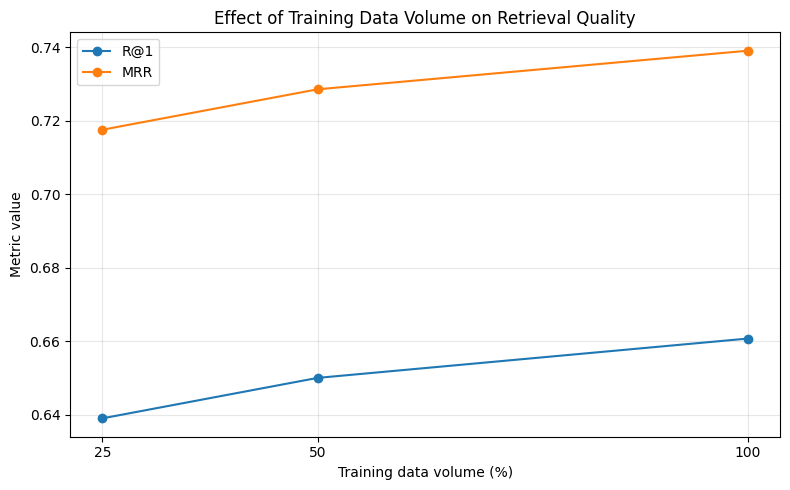

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(
    data_efficiency["train_percent"],
    data_efficiency["R@1"],
    marker="o",
    label="R@1"
)

plt.plot(
    data_efficiency["train_percent"],
    data_efficiency["MRR"],
    marker="o",
    label="MRR"
)

plt.xlabel("Training data volume (%)")
plt.ylabel("Metric value")
plt.title("Effect of Training Data Volume on Retrieval Quality")

plt.xticks([25, 50, 100])
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
with open(RESULTS_DIR / "paper_table1.json", "r", encoding="utf-8") as f:
    paper_table1 = json.load(f)

paper_table1

{'source': 'ArkTS-CodeSearch',
 'table': 'Table 1',
 'task': 'docstring_to_function_retrieval',
 'results': [{'model': 'EmbeddingGemma-300M',
   'condition': 'original',
   'metrics': {'mrr': 0.6399,
    'ndcg': 0.6654,
    'recall_at_1': 0.574,
    'recall_at_5': 0.7416}},
  {'model': 'EmbeddingGemma-300M',
   'condition': 'fine_tuned',
   'metrics': {'mrr': 0.7788,
    'ndcg': 0.8034,
    'recall_at_1': 0.7142,
    'recall_at_5': 0.8769}},
  {'model': 'Qwen3-0.6B',
   'condition': 'original',
   'metrics': {'mrr': 0.6776,
    'ndcg': 0.7015,
    'recall_at_1': 0.6141,
    'recall_at_5': 0.7723}},
  {'model': 'Qwen3-0.6B',
   'condition': 'fine_tuned',
   'metrics': {'mrr': 0.7745,
    'ndcg': 0.7971,
    'recall_at_1': 0.7146,
    'recall_at_5': 0.8643}},
  {'model': 'BGE-M3',
   'condition': 'original',
   'metrics': {'mrr': 0.5283,
    'ndcg': 0.5603,
    'recall_at_1': 0.4464,
    'recall_at_5': 0.6558}},
  {'model': 'BGE-M3',
   'condition': 'fine_tuned',
   'metrics': {'mrr': 0.

In [10]:
rows = []

for result in paper_table1["results"]:
    metrics = result["metrics"]

    rows.append({
        "model": result["model"],
        "condition": result["condition"],
        "MRR": metrics.get("mrr"),
        "NDCG": metrics.get("ndcg"),
        "R@1": metrics.get("recall_at_1"),
        "R@5": metrics.get("recall_at_5"),
        "R@10": metrics.get("recall_at_10")
    })

models_df = pd.DataFrame(rows)

models_df

,model,condition,MRR,NDCG,R@1,R@5,R@10
0,EmbeddingGemma-300M,original,0.6399,0.6654,0.5740,0.7416,NaN
1,EmbeddingGemma-300M,fine_tuned,0.7788,0.8034,0.7142,0.8769,NaN
2,Qwen3-0.6B,original,0.6776,0.7015,0.6141,0.7723,NaN
3,Qwen3-0.6B,fine_tuned,0.7745,0.7971,0.7146,0.8643,NaN
4,BGE-M3,original,0.5283,0.5603,0.4464,0.6558,NaN
5,BGE-M3,fine_tuned,0.7467,0.7729,0.6750,0.8504,NaN
6,BGE-zh,original,0.3598,0.3903,0.2841,0.4816,NaN
7,BGE-zh,fine_tuned,0.6748,0.7055,0.5961,0.7972,NaN
8,BGE-en,original,0.3439,0.3637,0.2935,0.4227,NaN
9,BGE-en,fine_tuned,0.4866,0.5144,0.4195,0.5977,NaN


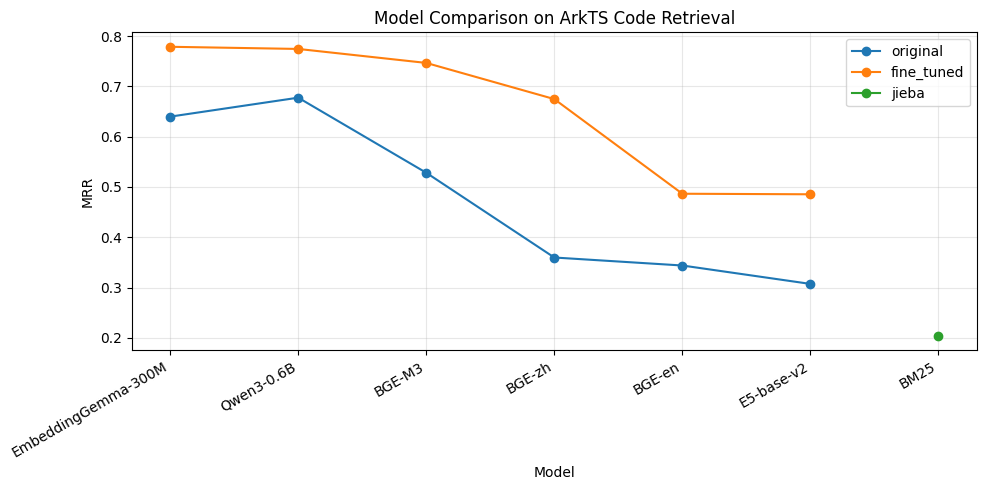

In [11]:
plt.figure(figsize=(10, 5))

for condition in models_df["condition"].unique():
    subset = models_df[models_df["condition"] == condition]

    plt.plot(
        subset["model"],
        subset["MRR"],
        marker="o",
        label=condition
    )

plt.xlabel("Model")
plt.ylabel("MRR")
plt.title("Model Comparison on ArkTS Code Retrieval")

plt.xticks(rotation=30, ha="right")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
with open(RESULTS_DIR / "paper_table2.json", "r", encoding="utf-8") as f:
    paper_table2 = json.load(f)

rows = []

for result in paper_table2["results"]:
    rows.append({
        "model": result["model"],
        "condition": result["condition"],
        "MRR": result["metrics"]["mrr"],
        "NDCG": result["metrics"]["ndcg"],
        "R@1": result["metrics"]["recall_at_1"],
        "R@5": result["metrics"]["recall_at_5"]
    })

transfer_df = pd.DataFrame(rows)

transfer_df

,model,condition,MRR,NDCG,R@1,R@5
0,EmbeddingGemma-300M,TS,0.6259,0.6525,0.5572,0.7318
1,EmbeddingGemma-300M,TS_to_ArkTS,0.8013,0.8229,0.7412,0.8867
2,Qwen3-0.6B,TS,0.6522,0.6785,0.5809,0.7563
3,Qwen3-0.6B,TS_to_ArkTS,0.7708,0.7947,0.7065,0.8655
4,BGE-M3,TS,0.6051,0.6338,0.5311,0.7191
5,BGE-M3,TS_to_ArkTS,0.7581,0.7846,0.6872,0.8630
6,BGE-zh,TS,0.5270,0.5571,0.4509,0.6468
7,BGE-zh,TS_to_ArkTS,0.6759,0.7032,0.6018,0.7841
8,E5-base-v2,TS,0.3751,0.3955,0.3226,0.4567
9,E5-base-v2,TS_to_ArkTS,0.4557,0.4821,0.3904,0.5613


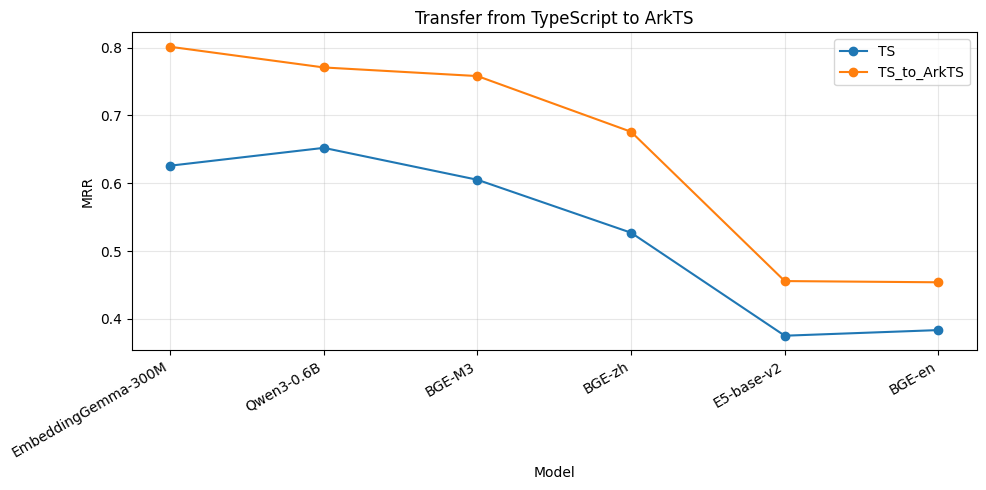

In [13]:
plt.figure(figsize=(10, 5))

for condition in transfer_df["condition"].unique():
    subset = transfer_df[transfer_df["condition"] == condition]

    plt.plot(
        subset["model"],
        subset["MRR"],
        marker="o",
        label=condition
    )

plt.xlabel("Model")
plt.ylabel("MRR")
plt.title("Transfer from TypeScript to ArkTS")

plt.xticks(rotation=30, ha="right")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Main observations

1. Fine-tuning improves the retrieval quality of EmbeddingGemma-300M
   compared with the zero-shot baseline.

2. Increasing the amount of specialized ArkTS training data from
   25% to 50% and 100% results in a consistent increase in R@1,
   R@5, MRR and NDCG@5.

3. The model comparison shows that fine-tuning affects different
   embedding models differently.

4. The TS → ArkTS experiments demonstrate the effect of
   ArkTS-specific adaptation in the transfer-learning setting.

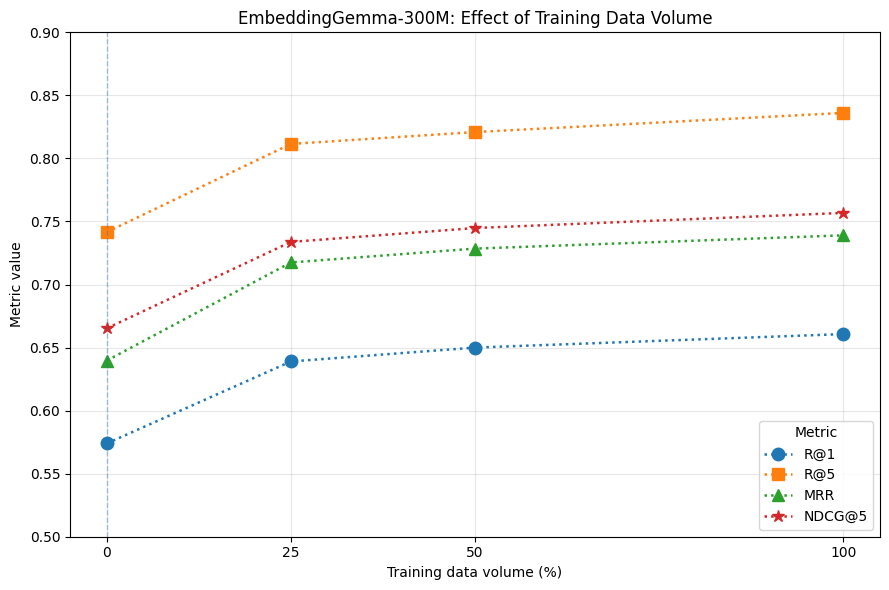

In [15]:
plt.figure(figsize=(9, 6))

# Zero-shot baseline
zero_shot = {
    "R@1": 0.5740,
    "R@5": 0.7416,
    "MRR": 0.6397,
    "NDCG@5": 0.6653,
}

metrics = ["R@1", "R@5", "MRR", "NDCG@5"]

# Different markers for metrics
markers = {
    "R@1": "o",
    "R@5": "s",
    "MRR": "^",
    "NDCG@5": "*",
}

# Plot each metric
for metric in metrics:
    x = [0] + data_efficiency["train_percent"].tolist()
    y = [zero_shot[metric]] + data_efficiency[metric].tolist()

    # Dotted line + points
    plt.plot(
        x,
        y,
        linestyle=":",
        linewidth=1.8,
        marker=markers[metric],
        markersize=9,
        label=metric
    )

# Mark zero-shot as a separate reference
plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1,
    alpha=0.4
)

plt.xlabel("Training data volume (%)")
plt.ylabel("Metric value")
plt.title("EmbeddingGemma-300M: Effect of Training Data Volume")

plt.xticks([0, 25, 50, 100])
plt.ylim(0.5, 0.9)

plt.grid(True, alpha=0.3)
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

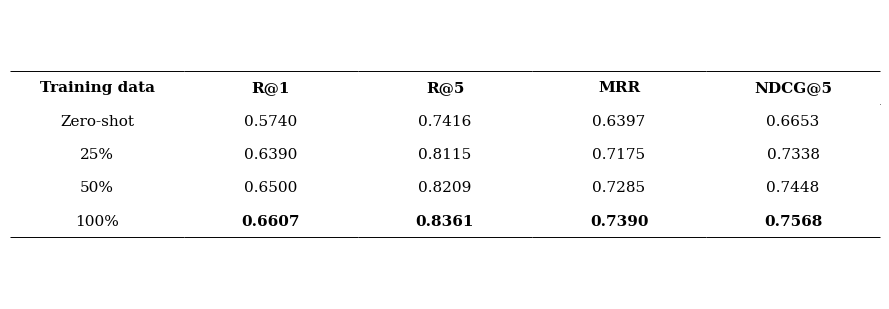

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------
# Results of our experiment
# ---------------------------------

experiment_table = pd.DataFrame({
    "Training data": [
        "Zero-shot",
        "25%",
        "50%",
        "100%"
    ],
    "R@1": [
        0.5740,
        0.6390,
        0.6500,
        0.6607
    ],
    "R@5": [
        0.7416,
        0.8115,
        0.8209,
        0.8361
    ],
    "MRR": [
        0.6397,
        0.7175,
        0.7285,
        0.7390
    ],
    "NDCG@5": [
        0.6653,
        0.7338,
        0.7448,
        0.7568
    ]
})

# Форматируем числа
display_table = experiment_table.copy()

for col in ["R@1", "R@5", "MRR", "NDCG@5"]:
    display_table[col] = display_table[col].map(
        lambda x: f"{x:.4f}"
    )


# ---------------------------------
# Table style
# ---------------------------------

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = [
    "Times New Roman",
    "Times",
    "DejaVu Serif"
]

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.axis("off")

table = ax.table(
    cellText=display_table.values,
    colLabels=display_table.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.7)


# ---------------------------------
# Cell styling
# ---------------------------------

for (row, col), cell in table.get_celld().items():

    cell.set_facecolor("white")
    cell.set_edgecolor("black")
    cell.set_linewidth(0)

    cell.get_text().set_fontfamily("serif")
    cell.get_text().set_fontsize(11)


# Header
for col in range(len(display_table.columns)):

    cell = table[(0, col)]

    cell.get_text().set_fontweight("bold")

    cell.visible_edges = "TB"
    cell.set_linewidth(0.7)


# Bottom border
last_row = len(display_table)

for col in range(len(display_table.columns)):

    cell = table[(last_row, col)]

    cell.visible_edges = "B"
    cell.set_linewidth(0.7)


# ---------------------------------
# Highlight best result
# ---------------------------------

for col in range(1, len(display_table.columns)):

    # последняя строка = 100%
    table[(last_row, col)].get_text().set_fontweight("bold")


plt.tight_layout()
plt.show()